# Lista 5 - SVM e Comitês de Modelos

## Questão 1

Considere o conjunto de dados disponível em **californiabin.csv**, organizado em 9 colunas, sendo as 8 primeiras colunas os atributos e a última coluna a saída. Os 8 atributos são usados na predição de preços, de casas em distritos da Califórnia na decáda de 1990. A saída é binária: 0, para abaixo da mediana dos preços; 1, para acima da mediana dos preços. 

a) Considerando uma divisão de 80% dos padrões para treinamento e 20% para teste, avalie modelos de classificação binária nos dados em questão. Para tanto, use as abordagens abaixo:
- **SVM:** Escolha um *kernel* RBF e use *grid-search* para ajustar os hiperparâmetros $C \left(\text{valores } 2^{-5},\, 2^{-3},\, 2^{-1},\, \cdots,\, 2^{11},\, 2^{13},\, 2^{15} \right)$ e $\gamma \left(\text{valores } 2^{-15},\, 2^{-13},\, 2^{-11},\, \cdots,\, 2^1,\, 2^2,\, 2^3 \right)$.
- **Random Forest:** Use *grid-search* para ajustar o número de classificadores base (valores 10, 20, ..., 180, 190, 200) e a máxima profundidade (*max depth*, valores 4, 6, 8, 10 ou máxima (None no sklearn)).

### **Solução**

In [2]:
import sys
sys.path.append("../")

#### Support Vector Machine (SVM)

In [3]:
# 1. Import das bibliotecas necessárias
from utils.utils import californiabin, treine_teste_divida, grid_search_SVM
from preprocessors.normalizador import Normalizador
from metrics.matrizdeconfusao import MatrizDeConfusaoBinaria
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

In [4]:
# 2. Extração dos dados
X = californiabin[:, :-1].copy()
y = californiabin[:, [-1]].copy()

In [5]:
# 3. Divisão dos dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = treine_teste_divida(X, y, train_size=0.8, random_state=42)

In [6]:
# 4. Normalização dos dados de treinamento via z-score
SVM_normalizador = Normalizador(X_train, method="StandardScaler")
X_train_normalizado = SVM_normalizador.normaliza(X_train)

In [10]:
# 5. Realizando o grid-search com k-fold cross validation para k = 10 (10 folds)
hyperparameter_search_space_SVM = {
    "C":[2 ** p for p in range(-5, 16, 2)],
    "gamma":[2 ** p for p in range(-15, 4, 2)]
}
Xy_train_normalizado = np.hstack([X_train_normalizado, y_train])
best_accuracy_SVM, best_hyperparameters_SVM = grid_search_SVM(hyperparameter_search_space_SVM, Xy_train_normalizado, 10)

#### Random Forest

In [7]:
# 1. Import das bibliotecas necessárias
from utils.utils import californiabin, treine_teste_divida, grid_search_RF, grid_search_RF_sklearn
from metrics.matrizdeconfusao import MatrizDeConfusaoBinaria
from models.florestaaleatoria import FlorestaAleatoria
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier

In [8]:
# 2. Extração dos dados
X = californiabin[:, :-1].copy()
y = californiabin[:, [-1]].copy()

In [9]:
# 3. Divisão dos dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = treine_teste_divida(X, y, train_size=0.8, random_state=42)

In [31]:
# 4. Realizando o grid-search com k-fold cross validation para k = 10 (10 folds)
hyperparameter_search_space_RF = {
    "n_modelos_base" :[n for n in range(10, 210, 10)],
    "profundidade_maxima":[4, 6, 8, 10, None]
}
Xy_train = np.hstack([X_train, y_train])
#best_accuracy_RF, best_hyperparameters_RF = grid_search_RF(hyperparameter_search_space_RF, Xy_train, 10)
best_accuracy_RF, best_hyperparameters_RF = grid_search_RF_sklearn(hyperparameter_search_space_RF, Xy_train, 10)

###
b) Para cada modelo campeão, reporte os hiperparâmetros selecionados e as métricas de **acurácia, revocação, precisão** e **F1-score** nos dados de teste. Plote também a **curva ROC** e a curva **Precision-Recall**.

### **Solução**

#### Support Vector Machine

In [11]:
# 6. Reporte dos hiperpâmetros de melhor acurácia
print(f"Melhores hiperparâmetros: (C, Gamma) = ({best_hyperparameters_SVM[0]}, {best_hyperparameters_SVM[1]})")
print(f"Melhor acurácia obtida na fase de otimização: {best_accuracy_SVM}")

Melhores hiperparâmetros: (C, Gamma) = (2048, 0.0078125)
Melhor acurácia obtida na fase de otimização: 0.8564324534161492


In [12]:
# 7. Treinamento do modelo com os hiperparâmetros otimizados
C, gamma = best_hyperparameters_SVM

classificador_binario_SVM = SVC(C=C, kernel="rbf", gamma=gamma, probability=True)
classificador_binario_SVM.fit(X_train_normalizado, y_train.ravel())

SVC(C=2048, gamma=0.0078125, probability=True)

In [13]:
# 8. Teste do modelo
X_test_normalizado = SVM_normalizador.normaliza(X_test)

y_pred = classificador_binario_SVM.predict(X_test_normalizado).reshape(-1,1)
y_proba = classificador_binario_SVM.predict_proba(X_test_normalizado)[:, 1]

In [14]:
# 9. Avaliação do modelo (métricas)

matriz_de_confusao_binaria_SVM = MatrizDeConfusaoBinaria(y_test, y_pred)
cm = [[matriz_de_confusao_binaria_SVM.TN, matriz_de_confusao_binaria_SVM.FP],
      [matriz_de_confusao_binaria_SVM.FN, matriz_de_confusao_binaria_SVM.TP]]
print(matriz_de_confusao_binaria_SVM)

[[178  29]
 [ 21 172]]


In [15]:
print("===================== Métricas do SVM =====================")
print(f"Acurácia: {matriz_de_confusao_binaria_SVM.acuracia()}")
print(f"Revocação: {matriz_de_confusao_binaria_SVM.revocacao()}")
print(f"Precisão: {matriz_de_confusao_binaria_SVM.precisao()}")
print(f"F1-score: {matriz_de_confusao_binaria_SVM.f1_score()}")

===================== Métricas do SVM =====================
Acurácia: 0.875
Revocação: 0.8911917098445595
Precisão: 0.8557213930348259
F1-score: 0.8730964467005076


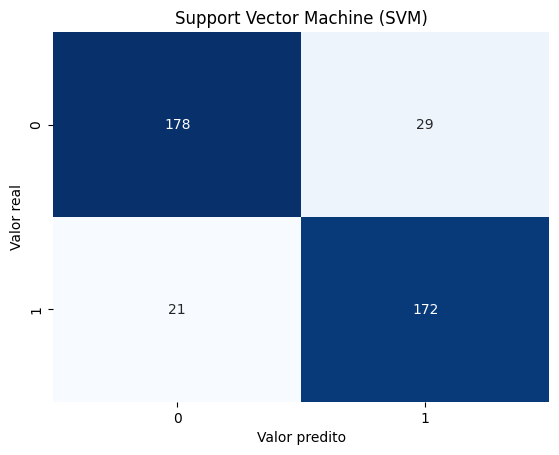

In [16]:
sns.heatmap(data=cm, annot=True, cmap="Blues", cbar=False, fmt=".0f")
plt.ylabel("Valor real")
plt.xlabel("Valor predito")
plt.title("Support Vector Machine (SVM)")
plt.show()

In [20]:
fpr, tpr, thresholds = roc_curve(y_test.ravel(), y_proba)
auc_score = roc_auc_score(y_test.ravel(), y_proba)

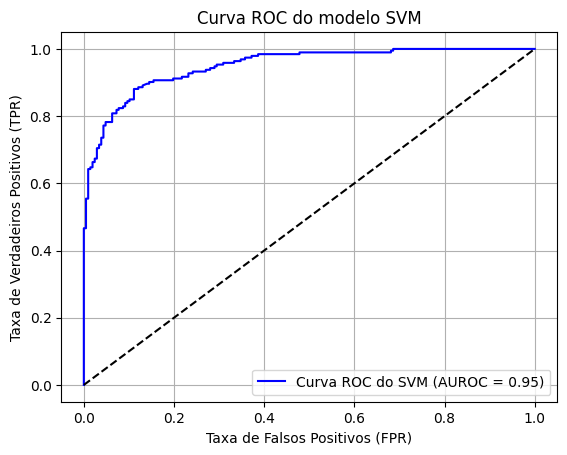

In [26]:
plt.plot(fpr, tpr, label=f"Curva ROC do SVM (AUROC = {auc_score:.2f})", color="b")
plt.plot([0, 1], [0, 1], "k--")
#plt.xlim([0,1])
#plt.ylim([0,1])
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC do modelo SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [23]:
precision, recall, thresholds = precision_recall_curve(y_test.ravel(), y_proba)
ap_score = average_precision_score(y_test.ravel(), y_proba)

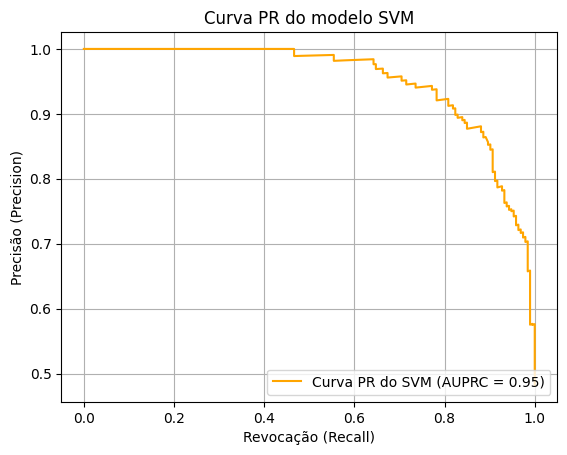

In [27]:
plt.plot(recall, precision, label=f"Curva PR do SVM (AUPRC = {ap_score:.2f})", color="orange")
#plt.xlim([0,1])
#plt.ylim([0,1])
plt.xlabel("Revocação (Recall)")
plt.ylabel("Precisão (Precision)")
plt.title("Curva PR do modelo SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Random Forest

In [33]:
# 5. Reporte dos hiperpâmetros de melhor acurácia
print(f"Melhores hiperparâmetros: (n_estimators, max_depth) = ({best_hyperparameters_RF[0]}, {best_hyperparameters_RF[1]})")
print(f"Melhor acurácia obtida na fase de otimização: {best_accuracy_RF}")

Melhores hiperparâmetros: (n_estimators, max_depth) = (190, 10)
Melhor acurácia obtida na fase de otimização: 0.860795807453416


In [34]:
# 6. Treinamento do modelo com os hiperparâmetros otimizados
n, p = best_hyperparameters_RF

classificador_binario_RF_sklearn = RandomForestClassifier(n_estimators=n, max_depth=p, bootstrap=True, n_jobs=-1, random_state=42)
classificador_binario_RF = FlorestaAleatoria(n_modelos_base=n, profundidade_maxima=p, random_state=42)
classificador_binario_RF_sklearn.fit(X_train, y_train.ravel())
classificador_binario_RF.ajuste(X_train, y_train)

In [40]:
# 7. Teste dos modelos
y_pred_RL = classificador_binario_RF_sklearn.predict(X_test).reshape(-1,1)
y_proba_RL = classificador_binario_RF_sklearn.predict_proba(X_test)[:, 1]

y_pred_FA = classificador_binario_RF.prever(X_test)
y_proba_FA = classificador_binario_RF.prever_proba(X_test)

In [51]:
# 8. Avaliação do modelo (métricas)

matriz_de_confusao_binaria_RF_sklearn = MatrizDeConfusaoBinaria(y_test, y_pred_RL)
cm_RF = [[matriz_de_confusao_binaria_RF_sklearn.TN, matriz_de_confusao_binaria_RF_sklearn.FP],
      [matriz_de_confusao_binaria_RF_sklearn.FN, matriz_de_confusao_binaria_RF_sklearn.TP]]
print("Random Forest (sklearn)")
print(matriz_de_confusao_binaria_RF_sklearn)
print()

matriz_de_confusao_binaria_FA = MatrizDeConfusaoBinaria(y_test, y_pred_FA)
cm_FA = [[matriz_de_confusao_binaria_FA.TN, matriz_de_confusao_binaria_FA.FP],
      [matriz_de_confusao_binaria_FA.FN, matriz_de_confusao_binaria_FA.TP]]
print("Floresta Aleatória")
print(matriz_de_confusao_binaria_FA)

Random Forest (sklearn)
[[185  22]
 [ 27 166]]

Floresta Aleatória
[[184  23]
 [ 27 166]]


In [48]:
print("===================== Métricas do Random Forest =====================")
print(f"Acurácia: {matriz_de_confusao_binaria_RF_sklearn.acuracia()}")
print(f"Revocação: {matriz_de_confusao_binaria_RF_sklearn.revocacao()}")
print(f"Precisão: {matriz_de_confusao_binaria_RF_sklearn.precisao()}")
print(f"F1-score: {matriz_de_confusao_binaria_RF_sklearn.f1_score()}")

===================== Métricas do Random Forest =====================
Acurácia: 0.8775
Revocação: 0.8601036269430051
Precisão: 0.8829787234042553
F1-score: 0.8713910761154856


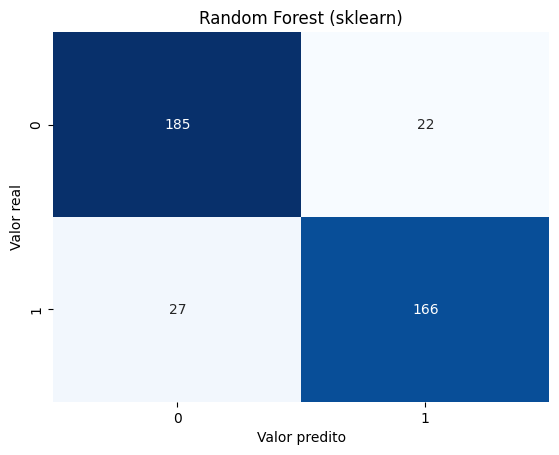

In [60]:
sns.heatmap(data=cm_RF, annot=True, cmap="Blues", cbar=False, fmt=".0f")
plt.ylabel("Valor real")
plt.xlabel("Valor predito")
plt.title("Random Forest (sklearn)")
plt.show()

In [53]:
fpr, tpr, thresholds = roc_curve(y_test.ravel(), y_proba_RL)
auc_score = roc_auc_score(y_test.ravel(), y_proba_RL)

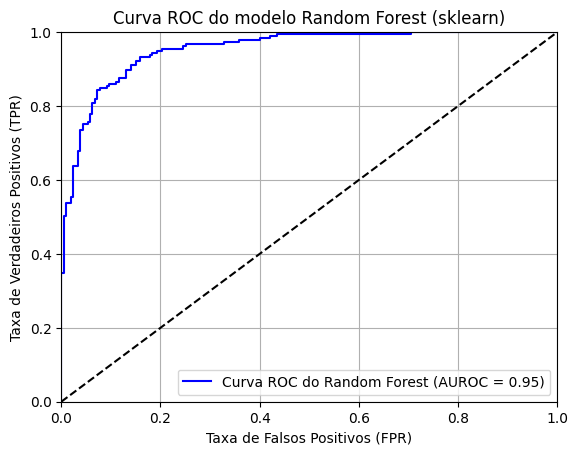

In [55]:
plt.plot(fpr, tpr, label=f"Curva ROC do Random Forest (AUROC = {auc_score:.2f})", color="b")
plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC do modelo Random Forest (sklearn)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [56]:
precision, recall, thresholds = precision_recall_curve(y_test.ravel(), y_proba_RL)
ap_score = average_precision_score(y_test.ravel(), y_proba)

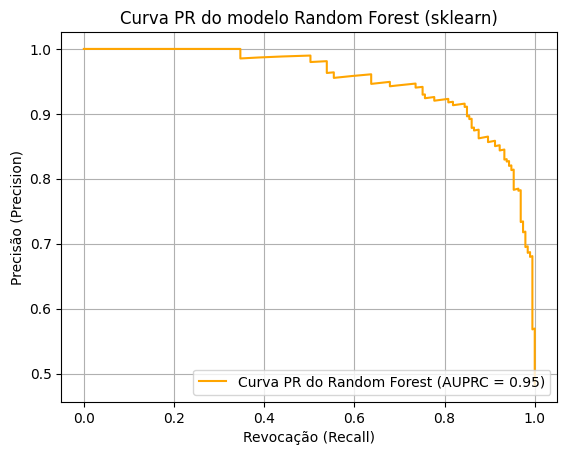

In [57]:
plt.plot(recall, precision, label=f"Curva PR do Random Forest (AUPRC = {ap_score:.2f})", color="orange")
#plt.xlim([0,1])
#plt.ylim([0,1])
plt.xlabel("Revocação (Recall)")
plt.ylabel("Precisão (Precision)")
plt.title("Curva PR do modelo Random Forest (sklearn)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [58]:
print("===================== Métricas do modelo Floresta Aleatória =====================")
print(f"Acurácia: {matriz_de_confusao_binaria_FA.acuracia()}")
print(f"Revocação: {matriz_de_confusao_binaria_FA.revocacao()}")
print(f"Precisão: {matriz_de_confusao_binaria_FA.precisao()}")
print(f"F1-score: {matriz_de_confusao_binaria_FA.f1_score()}")

===================== Métricas do modelo Floresta Aleatória =====================
Acurácia: 0.875
Revocação: 0.8601036269430051
Precisão: 0.8783068783068783
F1-score: 0.8691099476439791


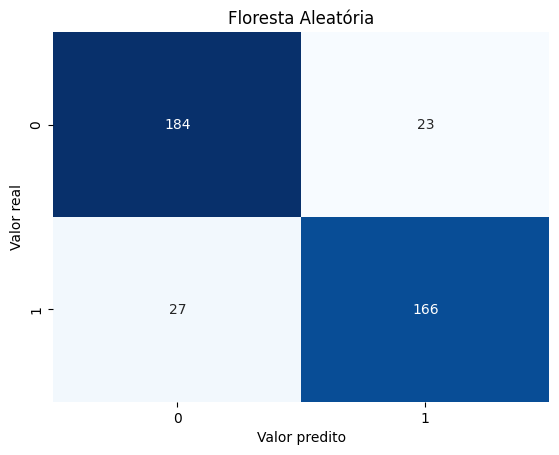

In [59]:
sns.heatmap(data=cm_FA, annot=True, cmap="Blues", cbar=False, fmt=".0f")
plt.ylabel("Valor real")
plt.xlabel("Valor predito")
plt.title("Floresta Aleatória")
plt.show()

In [64]:
fpr, tpr, thresholds = roc_curve(y_test.ravel(), y_proba_FA)
auc_score = roc_auc_score(y_test.ravel(), y_proba_FA)

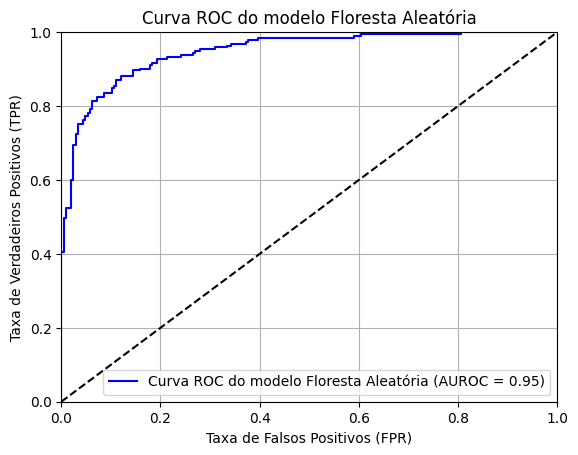

In [65]:
plt.plot(fpr, tpr, label=f"Curva ROC do modelo Floresta Aleatória (AUROC = {auc_score:.2f})", color="b")
plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC do modelo Floresta Aleatória")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [66]:
precision, recall, thresholds = precision_recall_curve(y_test.ravel(), y_proba_FA)
ap_score = average_precision_score(y_test.ravel(), y_proba_FA)

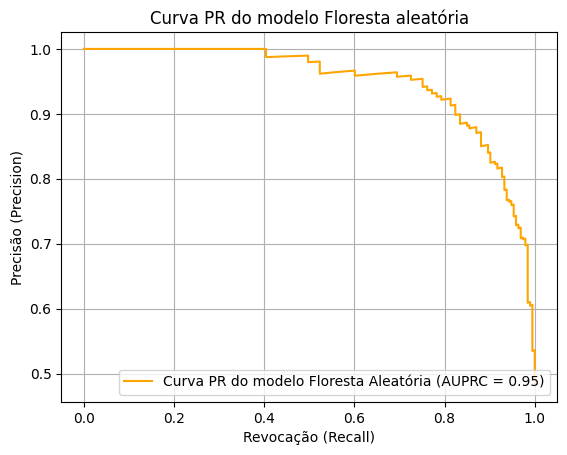

In [67]:
plt.plot(recall, precision, label=f"Curva PR do modelo Floresta Aleatória (AUPRC = {ap_score:.2f})", color="orange")
#plt.xlim([0,1])
#plt.ylim([0,1])
plt.xlabel("Revocação (Recall)")
plt.ylabel("Precisão (Precision)")
plt.title("Curva PR do modelo Floresta aleatória")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()